# Problem Statement

The energy provider is experiencing customer churn and believes that customers are becoming more sensitive to energy prices and are switching 
to lower-cost competitors. We need to determine whether price is the primary driver of churn or whether other factors contribute more significantly.

# Key Questions:

1. Why does the client believe customers are leaving? What is the churn rate?
2. Does price appear associated with churn? Determine whether energy price is the primary driver of churn and identify other important churn drivers.
3. What business impact does churn have?
4. Is price more important than everything else? This lets us determine whether price-related variables consistently rank among the strongest       predictors.
5. Who are our customers?
6. Which customers generate the revenue?
7. Which customers create the most long-term value?
8. What are the success criteria for the project?

# Import libraries

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from datetime import datetime


from matplotlib.patches import Patch
from matplotlib.lines import Line2D

# Shows plots in jupyter notebook
%matplotlib inline

# Set plot style
sns.set(color_codes=True)

ModuleNotFoundError: No module named 'matplotlib'

# Loading data with Pandas

We need to load `client_data.csv` and `price_data.csv` into individual dataframes so that we can work with them in Python. For this notebook and all further notebooks, it will be assumed that the CSV files will the placed in the same file location as the notebook. If they are not, please adjust the directory within the `read_csv` method accordingly.

In [1]:
df1 = pd.read_csv('client_data.csv')
df2 = pd.read_csv('price_data.csv')

NameError: name 'pd' is not defined

# Data combination

In [3]:
def find_join_candidates(df1, df2):
    candidates = []

    for c1 in df1.columns:
        for c2 in df2.columns:

            n1 = df1[c1].dropna().nunique()
            n2 = df2[c2].dropna().nunique()

            # Ignore low-cardinality columns
            if min(n1, n2) < 100:
                continue

            s1 = set(df1[c1].dropna())
            s2 = set(df2[c2].dropna())

            overlap = len(s1 & s2)

            strength = overlap / min(len(s1), len(s2))

            if strength > 0.95:
                candidates.append({
                    "Client_Column": c1,
                    "Price_Column": c2,
                    "Unique_Client": len(s1),
                    "Unique_Price": len(s2),
                    "Overlap": overlap,
                    "Strength": round(strength, 4)
                })

    return pd.DataFrame(candidates).sort_values(
        "Strength",
        ascending=False
    )

candidates = find_join_candidates(df1, df2)
#candidates.head(20)

In [4]:
# Left join (keep the client table)
data = pd.merge(df1, df2, on='id', how='inner')

data.to_csv('data.csv', index=False)                               

In [5]:
data

,id,channel_sales,cons_12m,cons_gas_12m,cons_last_month,date_activ,date_end,date_modif_prod,date_renewal,forecast_cons_12m,...,origin_up,pow_max,churn,price_date,price_off_peak_var,price_peak_var,price_mid_peak_var,price_off_peak_fix,price_peak_fix,price_mid_peak_fix
0,24011ae4ebbe3035111d65fa7c15bc57,foosdfpfkusacimwkcsosbicdxkicaua,0,54946,0,2013-06-15,2016-06-15,2015-11-01,2015-06-23,0.00,...,lxidpiddsbxsbosboudacockeimpuepw,43.648,1,2015-01-01,0.125976,0.103395,0.071536,40.565969,24.339581,16.226389
1,24011ae4ebbe3035111d65fa7c15bc57,foosdfpfkusacimwkcsosbicdxkicaua,0,54946,0,2013-06-15,2016-06-15,2015-11-01,2015-06-23,0.00,...,lxidpiddsbxsbosboudacockeimpuepw,43.648,1,2015-02-01,0.125976,0.103395,0.071536,40.565969,24.339581,16.226389
2,24011ae4ebbe3035111d65fa7c15bc57,foosdfpfkusacimwkcsosbicdxkicaua,0,54946,0,2013-06-15,2016-06-15,2015-11-01,2015-06-23,0.00,...,lxidpiddsbxsbosboudacockeimpuepw,43.648,1,2015-03-01,0.125976,0.103395,0.071536,40.565973,24.339578,16.226383
3,24011ae4ebbe3035111d65fa7c15bc57,foosdfpfkusacimwkcsosbicdxkicaua,0,54946,0,2013-06-15,2016-06-15,2015-11-01,2015-06-23,0.00,...,lxidpiddsbxsbosboudacockeimpuepw,43.648,1,2015-04-01,0.125976,0.103395,0.071536,40.565973,24.339578,16.226383
4,24011ae4ebbe3035111d65fa7c15bc57,foosdfpfkusacimwkcsosbicdxkicaua,0,54946,0,2013-06-15,2016-06-15,2015-11-01,2015-06-23,0.00,...,lxidpiddsbxsbosboudacockeimpuepw,43.648,1,2015-05-01,0.125976,0.103395,0.071536,40.565973,24.339578,16.226383
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
175144,563dde550fd624d7352f3de77c0cdfcd,MISSING,8730,0,0,2009-12-18,2016-12-17,2009-12-18,2015-12-21,762.41,...,ldkssxwpmemidmecebumciepifcamkci,10.392,0,2015-08-01,0.165962,0.086905,0.000000,44.266930,0.000000,0.000000
175145,563dde550fd624d7352f3de77c0cdfcd,MISSING,8730,0,0,2009-12-18,2016-12-17,2009-12-18,2015-12-21,762.41,...,ldkssxwpmemidmecebumciepifcamkci,10.392,0,2015-09-01,0.165962,0.086905,0.000000,44.266930,0.000000,0.000000
175146,563dde550fd624d7352f3de77c0cdfcd,MISSING,8730,0,0,2009-12-18,2016-12-17,2009-12-18,2015-12-21,762.41,...,ldkssxwpmemidmecebumciepifcamkci,10.392,0,2015-10-01,0.165962,0.086905,0.000000,44.266930,0.000000,0.000000
175147,563dde550fd624d7352f3de77c0cdfcd,MISSING,8730,0,0,2009-12-18,2016-12-17,2009-12-18,2015-12-21,762.41,...,ldkssxwpmemidmecebumciepifcamkci,10.392,0,2015-11-01,0.165962,0.086905,0.000000,44.266930,0.000000,0.000000


# Exploratory Data Analysis (EDA)

## Univariate Analysis

#### Data types

It is useful to first understand the data that you're dealing with along with the data types of each column. The data types may dictate how you transform and engineer features.

To get an overview of the data types within a data frame, use the `info()` method.

In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 175149 entries, 0 to 175148
Data columns (total 33 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   id                              175149 non-null  object 
 1   channel_sales                   175149 non-null  object 
 2   cons_12m                        175149 non-null  int64  
 3   cons_gas_12m                    175149 non-null  int64  
 4   cons_last_month                 175149 non-null  int64  
 5   date_activ                      175149 non-null  object 
 6   date_end                        175149 non-null  object 
 7   date_modif_prod                 175149 non-null  object 
 8   date_renewal                    175149 non-null  object 
 9   forecast_cons_12m               175149 non-null  float64
 10  forecast_cons_year              175149 non-null  int64  
 11  forecast_discount_energy        175149 non-null  float64
 12  forecast_meter_r

#### Descriptive statistics analysis of numerical data

Now let's look at some statistics about the datasets. We can do this by using the `describe()` method.

In [7]:
data.describe(include=['int64', 'int32'])

,cons_12m,cons_gas_12m,cons_last_month,forecast_cons_year,nb_prod_act,num_years_antig,churn
count,1.751490e+05,1.751490e+05,175149.000000,175149.000000,175149.00000,175149.000000,175149.000000
mean,1.592606e+05,2.808072e+04,16095.518404,1399.782380,1.29230,4.998276,0.097077
std,5.735413e+05,1.629400e+05,64376.741908,3248.331276,0.70978,1.611801,0.296064
min,0.000000e+00,0.000000e+00,0.000000,0.000000,1.00000,1.000000,0.000000
25%,5.674000e+03,0.000000e+00,0.000000,0.000000,1.00000,4.000000,0.000000
50%,1.411500e+04,0.000000e+00,792.000000,314.000000,1.00000,5.000000,0.000000
75%,4.076300e+04,0.000000e+00,3383.000000,1745.000000,1.00000,6.000000,0.000000
max,6.207104e+06,4.154590e+06,771203.000000,175375.000000,32.00000,13.000000,1.000000


In [8]:
data.describe(include=['float64'])

,forecast_cons_12m,forecast_discount_energy,forecast_meter_rent_12m,forecast_price_energy_off_peak,forecast_price_energy_peak,forecast_price_pow_off_peak,imp_cons,margin_gross_pow_ele,margin_net_pow_ele,net_margin,pow_max,price_off_peak_var,price_peak_var,price_mid_peak_var,price_off_peak_fix,price_peak_fix,price_mid_peak_fix
count,175149.000000,175149.000000,175149.000000,175149.000000,175149.000000,175149.000000,175149.000000,175149.000000,175149.000000,175149.000000,175149.000000,175149.000000,175149.000000,175149.000000,175149.000000,175149.000000,175149.000000
mean,1868.343884,0.967028,63.074649,0.137287,0.050487,43.130229,152.789831,24.566829,24.564223,189.245305,18.134896,0.142331,0.052059,0.028270,42.929009,9.458953,6.096434
std,2387.560169,5.109025,66.143996,0.024625,0.049036,4.486779,341.426992,20.234481,20.233588,311.846765,13.535809,0.023340,0.050286,0.036065,4.620531,12.133202,7.822250
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.300000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,494.980000,0.000000,16.180000,0.116340,0.000000,40.606701,0.000000,14.280000,14.280000,50.710000,12.500000,0.126595,0.000000,0.000000,40.728885,0.000000,0.000000
50%,1112.610000,0.000000,18.790000,0.143166,0.084138,44.311378,37.390000,21.640000,21.640000,112.500000,13.856000,0.146788,0.084213,0.000000,44.266930,0.000000,0.000000
75%,2400.350000,0.000000,131.030000,0.146348,0.098837,44.311378,193.990000,29.880000,29.880000,243.000000,19.180000,0.151635,0.102114,0.072900,44.444710,24.339581,16.226389
max,82902.830000,30.000000,599.310000,0.273963,0.195975,59.266378,15042.790000,374.640000,374.640000,24570.650000,320.000000,0.280700,0.229788,0.114102,59.444710,36.490689,17.458221


#### Descriptive statistics analysis of datetime data

##### Data transformation
Transforming dates to datetime data

In [9]:
date_cols = [
    'date_activ',
    'date_end',
    'date_modif_prod',
    'date_renewal',
    'price_date'
]

for col in date_cols:
    data[col] = pd.to_datetime(data[col], errors='coerce')



##### Datetime summary

In [10]:

data[date_cols].describe(include='datetime')

,date_activ,date_end,date_modif_prod,date_renewal,price_date
count,175149,175149,175149,175149,175149
mean,2011-01-28 04:01:02.401726720,2016-07-27 20:42:41.923847680,2013-01-02 04:53:06.434407168,2015-07-21 09:21:44.825034752,2015-06-16 12:39:54.203792896
min,2003-05-09 00:00:00,2016-01-28 00:00:00,2003-05-09 00:00:00,2013-06-26 00:00:00,2015-01-01 00:00:00
25%,2010-01-15 00:00:00,2016-04-27 00:00:00,2010-08-12 00:00:00,2015-04-17 00:00:00,2015-04-01 00:00:00
50%,2011-03-04 00:00:00,2016-08-01 00:00:00,2013-06-17 00:00:00,2015-07-27 00:00:00,2015-07-01 00:00:00
75%,2012-04-19 00:00:00,2016-10-31 00:00:00,2015-06-16 00:00:00,2015-10-29 00:00:00,2015-10-01 00:00:00
max,2014-09-01 00:00:00,2017-06-13 00:00:00,2016-01-29 00:00:00,2016-01-28 00:00:00,2015-12-01 00:00:00


In [11]:
summary = pd.DataFrame({
    'Missing Values': data[date_cols].isnull().sum(),
    'Unique Dates': data[date_cols].nunique(),
    'Earliest Date': data[date_cols].min(),
    'Latest Date': data[date_cols].max(),
    'Range (Days)': (data[date_cols].max() - data[date_cols].min()).dt.days,
    'Median Date': data[date_cols].median(),
    'Mean Date': data[date_cols].mean(),
    'Mode Date': [
        data[col].mode().iloc[0] if not data[col].mode().empty else pd.NaT
        for col in date_cols
    ]
})

summary

,Missing Values,Unique Dates,Earliest Date,Latest Date,Range (Days),Median Date,Mean Date,Mode Date
date_activ,0,1796,2003-05-09,2014-09-01,4133,2011-03-04,2011-01-28 04:01:02.401726720,2009-08-01
date_end,0,368,2016-01-28,2017-06-13,502,2016-08-01,2016-07-27 20:42:41.923847680,2016-02-01
date_modif_prod,0,2129,2003-05-09,2016-01-29,4648,2013-06-17,2013-01-02 04:53:06.434407168,2015-11-01
date_renewal,0,386,2013-06-26,2016-01-28,946,2015-07-27,2015-07-21 09:21:44.825034752,2015-06-23
price_date,0,12,2015-01-01,2015-12-01,334,2015-07-01,2015-06-16 12:39:54.203792896,2015-08-01


#### Categorical summary

In [12]:
data.describe(include='object')                                             # Categorical summary

,id,channel_sales,has_gas,origin_up
count,175149,175149,175149,175149
unique,14606,8,2,6
top,24011ae4ebbe3035111d65fa7c15bc57,foosdfpfkusacimwkcsosbicdxkicaua,f,lxidpiddsbxsbosboudacockeimpuepw
freq,12,80971,143364,85086


#### Duplicates

In [13]:
data.duplicated().sum()     

0

#### Missing values

In [14]:
cols_with_missing = []

for col in data.columns:
    missing_count = (data[col] == 'MISSING').sum()
    if missing_count > 0:
        print(f"{col}: {missing_count}")
        cols_with_missing.append(col)

channel_sales: 44684
origin_up: 767


#### Handling missing variables 
Fill missing values with "Unknown"

In [15]:
# Create an explicit category for missing values
data["channel_sales"] = data["channel_sales"].fillna("Unknown")
data["origin_up"] = data["origin_up"].fillna("Unknown")

In [16]:
# Verify the result
print("Missing values after treatment:")

print("channel_sales:", data["channel_sales"].isna().sum())
print("origin_up:", data["origin_up"].isna().sum())

Missing values after treatment:
channel_sales: 0
origin_up: 0


---

## Data visualization

If you're working in Python, two of the most popular packages for visualization are `matplotlib` and `seaborn`. We highly recommend you use these, or at least be familiar with them because they are ubiquitous!

Below are some functions that you can use to get started with visualizations. 

## Bi-variate Analysis

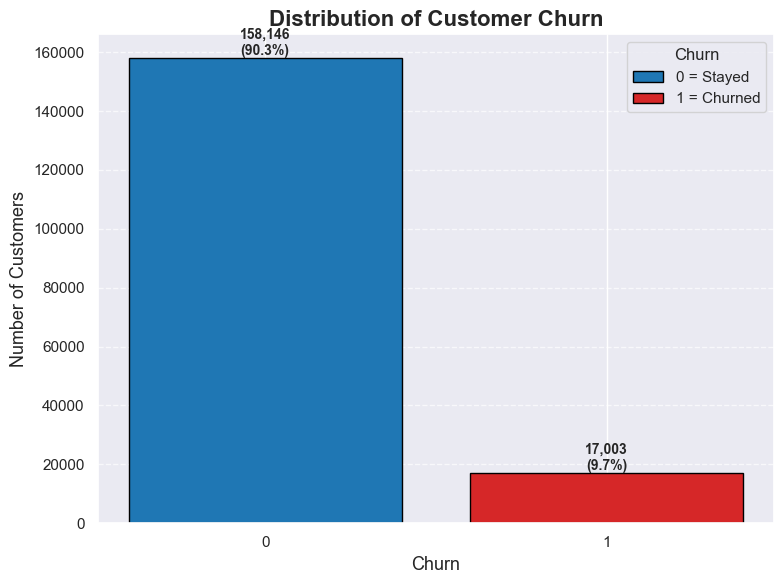

In [17]:

from matplotlib.patches import Patch

# Churn Distribution
churn_counts = data['churn'].value_counts().sort_index()

total_customers = churn_counts.sum()

# Define colors
palette = {
    0: '#1f77b4',   # Blue = Stayed
    1: '#d62728'    # Red = Churned
}

plt.figure(figsize=(8, 6))

# Plot bars with x-axis labels 0 and 1
bars = plt.bar(
    churn_counts.index.astype(str),
    churn_counts.values,
    color=[palette[i] for i in churn_counts.index],
    edgecolor='black',
    linewidth=1
)

# Title and axis labels
plt.title('Distribution of Customer Churn', fontsize=16, fontweight='bold')
plt.xlabel('Churn', fontsize=13)
plt.ylabel('Number of Customers', fontsize=13)

# Add count and percentage labels above bars
for bar in bars:

    count = int(bar.get_height())
    percentage = (count / total_customers) * 100

    plt.text(
        bar.get_x() + bar.get_width() / 2,
        count,
        f'{count:,}\n({percentage:.1f}%)',
        ha='center',
        va='bottom',
        fontsize=10,
        fontweight='bold'
    )

# Legend
legend_elements = [
    Patch(facecolor=palette[0], edgecolor='black', label='0 = Stayed'),
    Patch(facecolor=palette[1], edgecolor='black', label='1 = Churned')
]

plt.legend(
    handles=legend_elements,
    title='Churn',
    loc='upper right',
    fontsize=11,
    title_fontsize=12
)

# Grid
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

####### This is better than the industry average of 15-25% for energy/telecom sectors, it still represents a significant revenue leak. 
At 9.7%, the company is retaining ~90% of customers — but the quality of those retained customers matters. 
The histograms show extreme right-skewness in consumption (most customers are low-usage), meaning the 9.7% churn may disproportionately include high-value customers.

## Multi-variate Analysis

##### Violin plots -  association/distribution differences



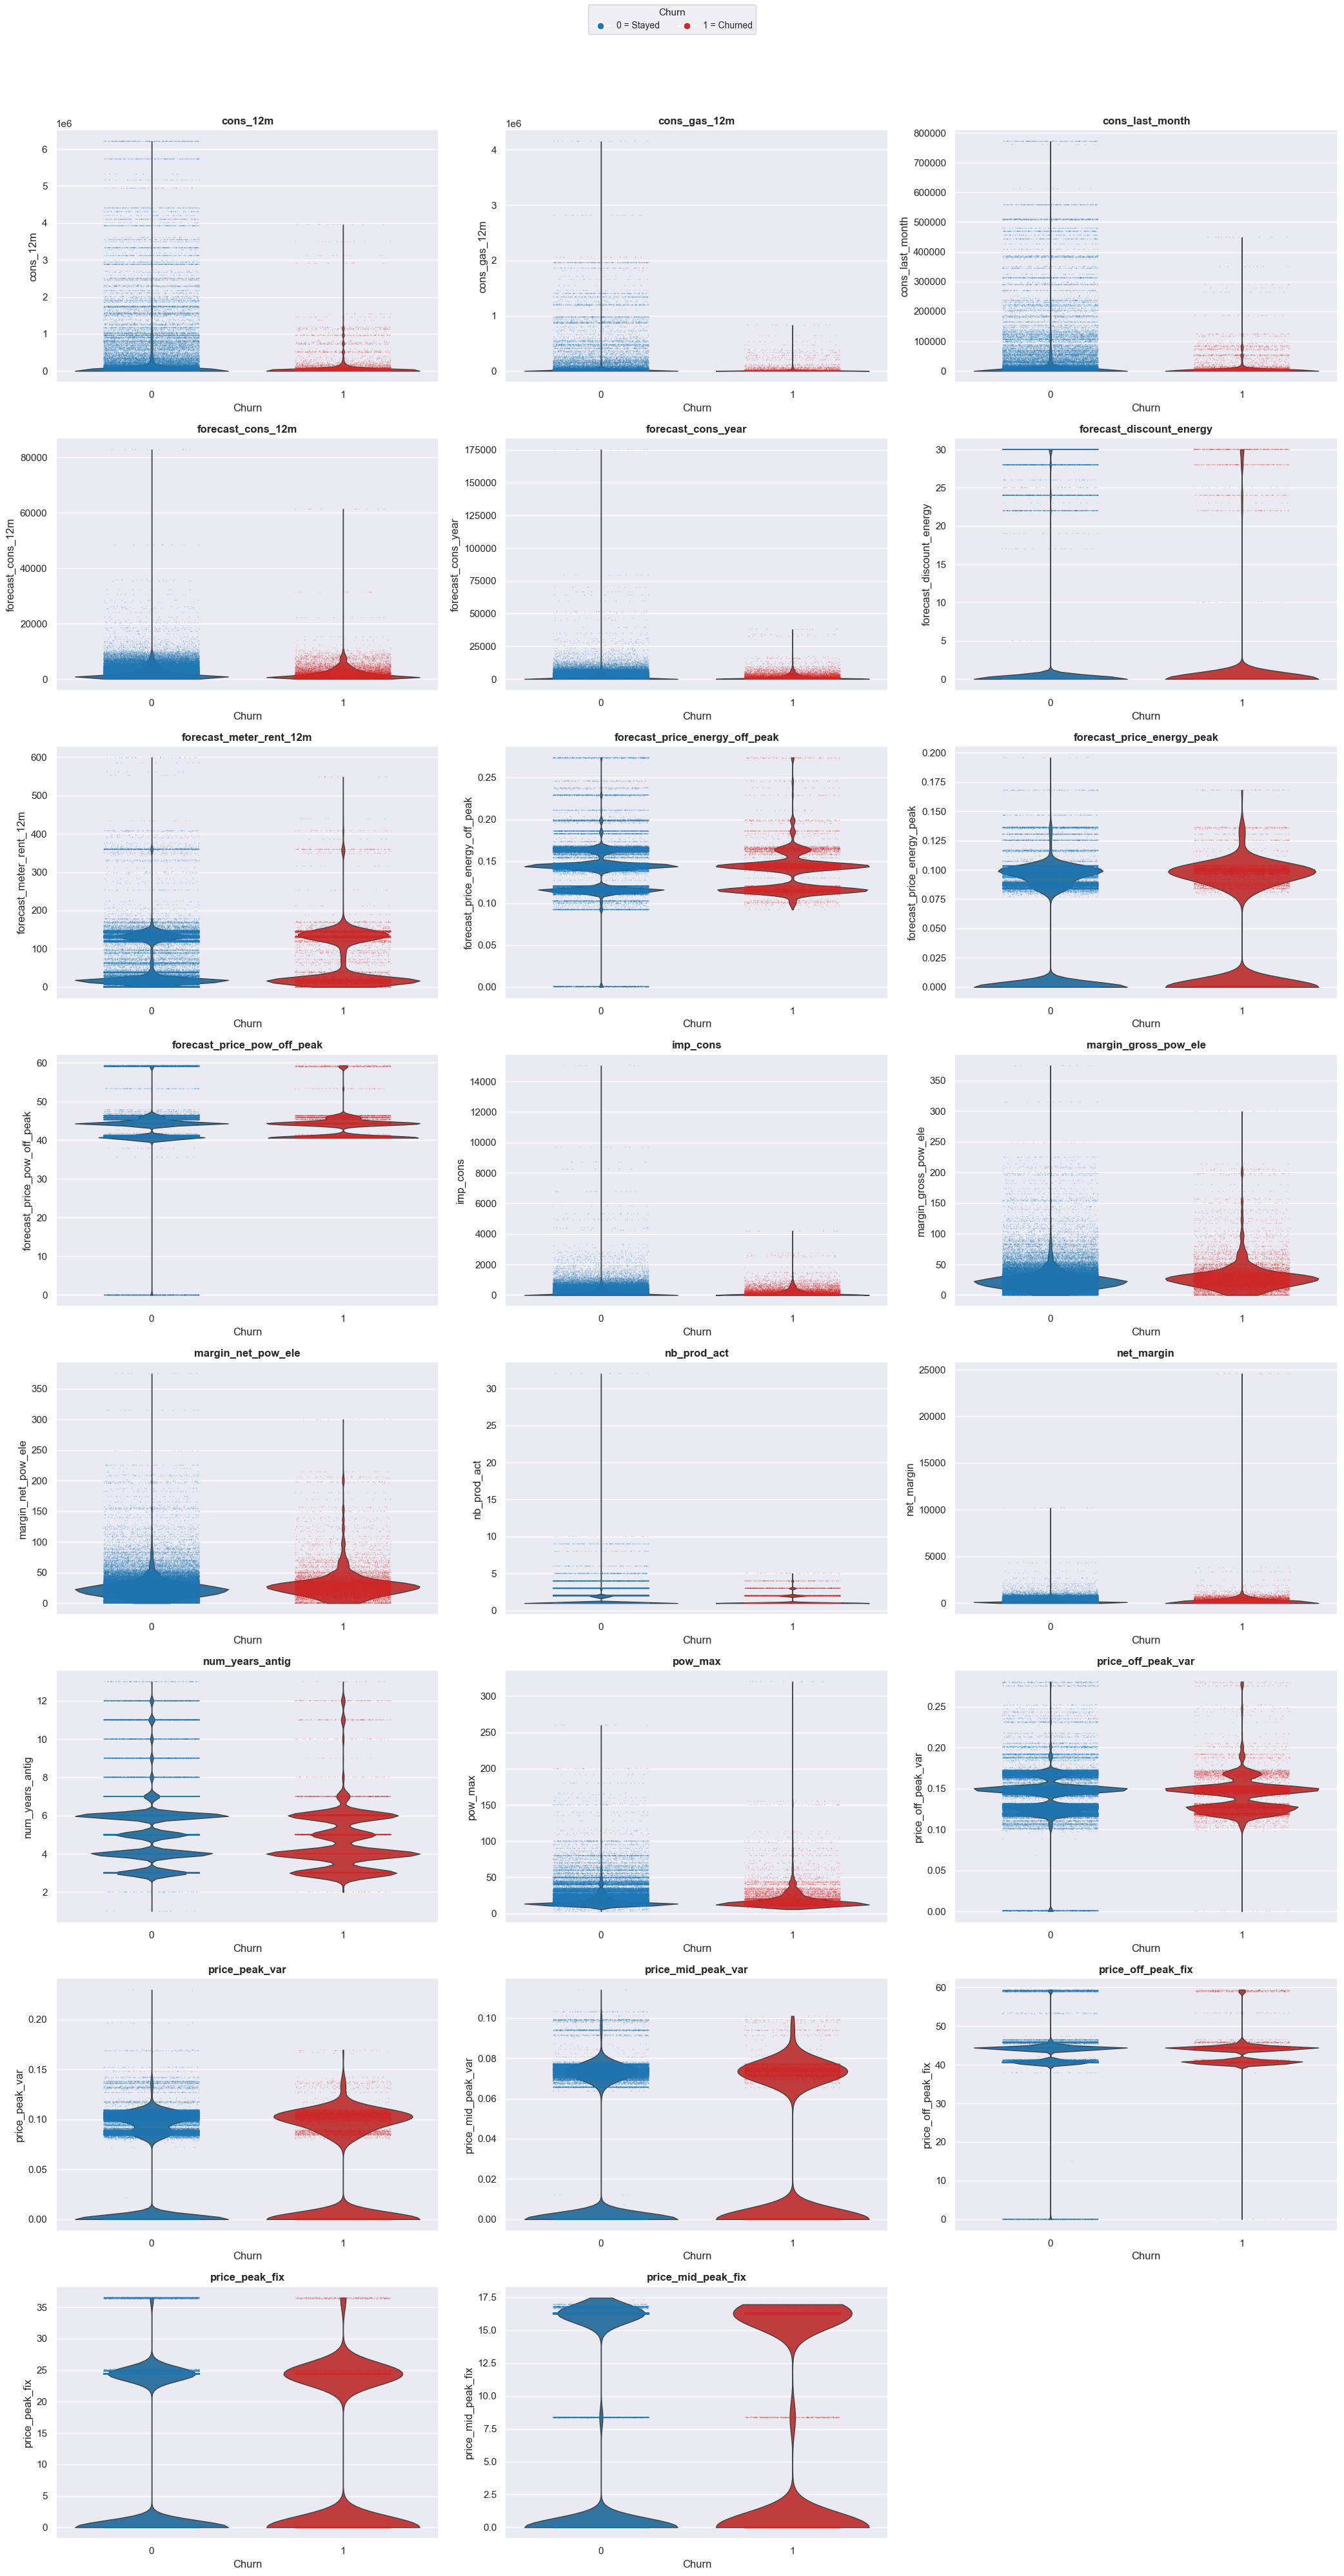

In [18]:

from matplotlib.lines import Line2D

# Extract numerical columns (excluding churn)
numeric_cols = data.select_dtypes(
    include=['int32', 'int64', 'float32', 'float64']
).columns
numeric_cols = numeric_cols.drop(['churn'], errors='ignore')

# Define colors
palette = {
    0: '#1f77b4',   # Blue = Stayed
    1: '#d62728'    # Red = Churned
}

# Create subplot grid
cols = 3
rows = (len(numeric_cols) + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(7 * cols, 5 * rows))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):

    # Violin plot
    sns.violinplot(
        data=data,
        x='churn',
        y=col,
        hue='churn',
        palette=palette,
        legend=False,
        inner=None,
        cut=0,
        linewidth=1,
        ax=axes[i]
    )

    # Overlay all observations
    sns.stripplot(
        data=data,
        x='churn',
        y=col,
        hue='churn',
        palette=palette,
        dodge=False,
        jitter=0.25,
        size=1.2,
        alpha=0.20,
        legend=False,
        ax=axes[i]
    )

    axes[i].set_title(col, fontsize=12, fontweight='bold')
    axes[i].set_xlabel("Churn")
    axes[i].set_ylabel(col)

    # Keep x-axis ticks as 0 and 1
    axes[i].set_xticks([0, 1])
    axes[i].set_xticklabels(['0', '1'])

# Hide unused subplots
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

# -------- Global Legend --------
legend_elements = [
    Line2D(
        [0], [0],
        marker='o',
        color='w',
        markerfacecolor=palette[0],
        markersize=8,
        label='0 = Stayed'
    ),
    Line2D(
        [0], [0],
        marker='o',
        color='w',
        markerfacecolor=palette[1],
        markersize=8,
        label='1 = Churned'
    )
]

fig.legend(
    handles=legend_elements,
    title='Churn',
    loc='upper center',
    ncol=2,
    fontsize=10,
    title_fontsize=11
)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

The violin plots indicate that consumption-related variables exhibit more noticeable distributional differences between churned and non-churned customers,
while the energy price variables show substantial overlap between the two groups. This provides preliminary evidence that price alone may not be the primary driver of churn. 
However, visual analysis cannot establish statistical significance or causality. Therefore, statistical testing and predictive modeling with feature-importance and
explainability techniques are required to determine whether price or other customer characteristics are the strongest drivers of churn.

##### Identify outliers

In [ ]:


# Extract numerical columns (excluding churn)
numeric_cols = data.select_dtypes(
    include=['int32', 'int64', 'float32', 'float64']
).columns
numeric_cols = numeric_cols.drop(['churn'], errors='ignore')

# Define colors
palette = {
    0: '#1f77b4',   # Blue = Stayed
    1: '#d62728'    # Red = Churned
}

# Create subplot grid
cols = 2
rows = (len(numeric_cols) + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(7 * cols, 5 * rows))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):

    sns.boxplot(
        data=data,
        x='churn',
        y=col,
        hue='churn',
        palette=palette,
        showfliers=True,
        legend=False,
        ax=axes[i]
    )

    axes[i].set_title(col, fontsize=12, fontweight='bold')
    axes[i].set_xlabel("Churn")
    axes[i].set_ylabel(col)

    # Ensure x-axis shows 0 and 1
    axes[i].set_xticks([0, 1])
    axes[i].set_xticklabels(['0', '1'])

# Hide unused subplots
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

# -------- Global Legend --------
legend_elements = [
    Patch(
        facecolor=palette[0],
        edgecolor='black',
        label='0 = Stayed'
    ),
    Patch(
        facecolor=palette[1],
        edgecolor='black',
        label='1 = Churned'
    )
]

fig.legend(
    handles=legend_elements,
    title='Churn',
    loc='upper center',
    ncol=2,
    fontsize=10,
    title_fontsize=11
)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

##### Distributions of variables of objects

In [ ]:

# Extract object columns
object_cols = data.select_dtypes(include='object').columns

# Remove ID column if present
object_cols = object_cols.drop(['id'], errors='ignore')

# Colors
palette = {
    0: '#1f77b4',   # Blue = Stayed
    1: '#d62728'    # Red = Churned
}

# Create subplot grid
cols = 2
rows = (len(object_cols) + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(9 * cols, 6 * rows))
axes = axes.flatten()

for i, col in enumerate(object_cols):

    # Crosstab: category vs churn
    counts = pd.crosstab(data[col], data['churn'])

    # Ensure both classes exist
    counts = counts.reindex(columns=[0, 1], fill_value=0)

    # Plot stacked bars
    counts.plot(
        kind='bar',
        stacked=True,
        color=[palette[0], palette[1]],
        edgecolor='black',
        ax=axes[i]
    )

    totals = counts.sum(axis=1)

    # Total observations for percentage calculation
    global_total = counts.values.sum()

    # Annotate bars
    for x, category in enumerate(counts.index):

        stayed = counts.loc[category, 0]
        churned = counts.loc[category, 1]
        total = stayed + churned

        # Stayed %
        if stayed > 0:
            axes[i].text(
                x,
                stayed / 2,
                f"{100 * stayed / global_total:.1f}%",
                ha='center',
                va='center',
                fontsize=8,
                fontweight='bold',
                color='white'
            )

        # Churned %
        if churned > 0:
            axes[i].text(
                x,
                stayed + churned / 2,
                f"{100 * churned / global_total:.1f}%",
                ha='center',
                va='center',
                fontsize=8,
                fontweight='bold',
                color='white'
            )

        # Total count
        axes[i].text(
            x,
            total,
            f"n={total:,}",
            ha='center',
            va='bottom',
            fontsize=8,
            fontweight='bold'
        )

    axes[i].set_title(col, fontsize=13, fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Count")
    axes[i].tick_params(axis='x', rotation=45)

    # Remove subplot legend
    if axes[i].get_legend() is not None:
        axes[i].get_legend().remove()

# Hide unused subplots
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

# Global legend
legend_elements = [
    Patch(facecolor=palette[0], edgecolor='black', label='0 = Stayed'),
    Patch(facecolor=palette[1], edgecolor='black', label='1 = Churned')
]

fig.legend(
    handles=legend_elements,
    title='Churn',
    loc='upper center',
    ncol=2,
    fontsize=10,
    title_fontsize=11
)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

In [ ]:
numeric_cols = data.select_dtypes(
    include=['int32', 'int64', 'float32', 'float64']
).columns
#numeric_co

In [ ]:

# Extract numeric columns (excluding the 'Id' and ''Drafted' columns)
numeric_cols = data.select_dtypes(include=['number'])

# Compute the correlation matrix
corr_matrix = numeric_cols.corr()

# Plot a heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    vmin=-1, vmax=1,
    square=True,
    linewidths=0.5
)

plt.title('Correlation Matrix of Numeric Features', fontsize=16)
plt.show()

In [ ]:
data['churn_label'] = data['churn'].map({
    0: 'Stayed',
    1: 'Churned'
})


pair_sample = data.sample(
    n=min(5000, len(data)),
    random_state=42
)

sns.pairplot(
    pair_sample,
    hue='churn_label',
    corner=True,
    diag_kind='kde'
)

plt.show()

### Churn analysis

In [ ]:
# Create a new dataset
df = data.copy()


In [ ]:
consumption = df[['id', 'cons_12m', 'cons_gas_12m', 'cons_last_month', 'imp_cons', 'has_gas', 'churn']]

In [ ]:
def plot_distribution(df, column, ax, bins_=50):
    """
    Plot variable distribution in a stacked histogram of churned or retained company
    """
    # Create a temporal dataframe with the data to be plot
    temp = pd.DataFrame({"Stayed": df[df["churn"]==0][column],
    "Churn":df[df["churn"]==1][column]})
    # Plot the histogram
    temp[["Stayed","Churn"]].plot(kind='hist', bins=bins_, ax=ax, stacked=True)
    # X-axis label
    ax.set_xlabel(column)
    # Change the x-axis to plain style
    ax.ticklabel_format(style='plain', axis='x')

fig, axs = plt.subplots(nrows=4, figsize=(18, 25))

plot_distribution(consumption, 'cons_12m', axs[0])
plot_distribution(consumption[consumption['has_gas'] == 't'], 'cons_gas_12m', axs[1])
plot_distribution(consumption, 'cons_last_month', axs[2])
plot_distribution(consumption, 'imp_cons', axs[3])

In [ ]:

price_df = df.groupby('churn')[['price_off_peak_fix', 'price_peak_fix','price_mid_peak_fix']].mean()

# -----------------------------
# GLOBAL TOTAL (ALL VALUES)
# -----------------------------
global_total = price_df.values.sum()

# percentage relative to ENTIRE dataset
price_pct_global = (price_df / global_total) * 100

# plot
ax = price_df.T.plot(kind='bar', figsize=(10,6))

plt.title("Energy Price Metrics vs Churn (Value + Global % share)")
plt.xlabel("Metric")
plt.ylabel("Average Value")
plt.xticks(rotation=0)

metrics = price_df.columns
churn_groups = price_df.index

# -----------------------------
# ANNOTATION (GLOBAL %)
# -----------------------------
for i_metric, metric in enumerate(metrics):

    for j_churn, churn in enumerate(churn_groups):

        value = price_df.loc[churn, metric]
        pct = price_pct_global.loc[churn, metric]

        x_pos = i_metric + (j_churn - 0.5) * 0.25

        ax.text(
            x_pos,
            value * 0.5,
            f"{value:.1f}\n({pct:.1f}%)",
            ha='center',
            va='center',
            fontsize=8,
            color='black',
            fontweight='bold'
        )

plt.legend(title="Churn")
plt.tight_layout()
plt.show()

######## Price-driven churn: churners have higher price_off_peak_fix, price_peak_fix and price_mid_peak_fix. 
Finding: Churned customers pay 20.4% more for peak fixed power and 20.0% more for mid-peak fixed power. Off-peak prices are nearly identical (+0.7%).
Interpretation: This confirms the client's hypothesis — price sensitivity during peak periods is the strongest churn trigger. 
The histograms for price_peak_fix and price_mid_peak_fix show clear bimodal distributions with churned customers clustered in higher price tiers. 
The correlation heatmap confirms price_peak_fix and price_mid_peak_fix have the strongest positive correlation with churn.
Business implication: Peak-period pricing is punitive for certain customer segments. The company should investigate whether:
These customers are on outdated/legacy tariffs
Competitors offer significantly lower peak rates
Dynamic pricing or time-of-use plans could retain them.


In [ ]:

price_df = df.groupby('churn')[['cons_12m','cons_gas_12m','cons_last_month']].mean()

# -----------------------------
# GLOBAL TOTAL (ALL VALUES)
# -----------------------------
global_total = price_df.values.sum()

# percentage relative to ENTIRE dataset
price_pct_global = (price_df / global_total) * 100

# plot
ax = price_df.T.plot(kind='bar', figsize=(10,6))

plt.title("Consumtion Metrics vs Churn (Value + Global % share)")
plt.xlabel("Metric")
plt.ylabel("Average Value")
plt.xticks(rotation=0)

metrics = price_df.columns
churn_groups = price_df.index

# -----------------------------
# ANNOTATION (GLOBAL %)
# -----------------------------
for i_metric, metric in enumerate(metrics):

    for j_churn, churn in enumerate(churn_groups):

        value = price_df.loc[churn, metric]
        pct = price_pct_global.loc[churn, metric]

        x_pos = i_metric + (j_churn - 0.5) * 0.25

        ax.text(
            x_pos,
            value * 0.5,
            f"{value:.1f}\n({pct:.1f}%)",
            ha='center',
            va='center',
            fontsize=8,
            color='black',
            fontweight='bold'
        )

plt.legend(title="Churn")
plt.tight_layout()
plt.show()

##### Consumption-driven churn: churners consum less energy.
Finding: Churned customers consume 53% less electricity, 69% less gas, and 58% less in the last month.
Interpretation: Low consumption is a leading indicator of churn. The histograms for cons_12m, cons_gas_12m, and cons_last_month all show extreme right-skewness
with churned customers concentrated in the lowest bins. This suggests:
Small businesses (low usage) are most at risk
Seasonal/irregular users lack engagement
Customers who "set and forget" their contracts are more likely to switch when prices rise
Business implication: Low-consumption customers need different retention strategies — perhaps flat-rate plans, bundled services, or loyalty programs rather than volume-based discounts.

In [ ]:

price_df = data.groupby('churn')[['forecast_price_energy_off_peak','forecast_price_energy_peak','forecast_price_pow_off_peak']].mean()

# -----------------------------
# GLOBAL TOTAL (ALL VALUES)
# -----------------------------
global_total = price_df.values.sum()

# percentage relative to ENTIRE dataset
price_pct_global = (price_df / global_total) * 100

# plot
ax = price_df.T.plot(kind='bar', figsize=(10,6))

plt.title("Forcast Metrics vs Churn (Value + Global % share)")
plt.xlabel("Metric")
plt.ylabel("Average Value")
plt.xticks(rotation=0)

metrics = price_df.columns
churn_groups = price_df.index

# -----------------------------
# ANNOTATION (GLOBAL %)
# -----------------------------
for i_metric, metric in enumerate(metrics):

    for j_churn, churn in enumerate(churn_groups):

        value = price_df.loc[churn, metric]
        pct = price_pct_global.loc[churn, metric]

        x_pos = i_metric + (j_churn - 0.5) * 0.25

        ax.text(
            x_pos,
            value * 0.5,
            f"{value:.1f}\n({pct:.1f}%)",
            ha='center',
            va='center',
            fontsize=8,
            color='black',
            fontweight='bold'
        )

plt.legend(title="Churn")
plt.tight_layout()
plt.show()

In [ ]:

price_df = data.groupby('churn')[['margin_gross_pow_ele','margin_net_pow_ele','net_margin']].mean()

# -----------------------------
# GLOBAL TOTAL (ALL VALUES)
# -----------------------------
global_total = price_df.values.sum()

# percentage relative to ENTIRE dataset
price_pct_global = (price_df / global_total) * 100

# plot
ax = price_df.T.plot(kind='bar', figsize=(10,6))

plt.title("Margin Metrics vs Churn (Value + Global % share)")
plt.xlabel("Metric")
plt.ylabel("Average Value")
plt.xticks(rotation=0)

metrics = price_df.columns
churn_groups = price_df.index

# -----------------------------
# ANNOTATION (GLOBAL %)
# -----------------------------
for i_metric, metric in enumerate(metrics):

    for j_churn, churn in enumerate(churn_groups):

        value = price_df.loc[churn, metric]
        pct = price_pct_global.loc[churn, metric]

        x_pos = i_metric + (j_churn - 0.5) * 0.25

        ax.text(
            x_pos,
            value * 0.5,
            f"{value:.1f}\n({pct:.1f}%)",
            ha='center',
            va='center',
            fontsize=8,
            color='black',
            fontweight='bold'
        )

plt.legend(title="Churn")
plt.tight_layout()
plt.show()

###### Finding: Churned customers generate 38-45% lower margins across all margin metrics.
Interpretation: While churners are lower-margin customers, the absolute loss is still significant because:
Customer acquisition cost (CAC) in B2B energy is high
The 17,003 churned customers represent sunk acquisition investment
The net_margin histogram shows most customers cluster near zero — even small margin losses matter at scale
Business implication: The company is losing both volume and value. Retention should focus on margin protection, not just volume.

#### Customer Tenure

Questions:
Are newer customers churning more?
Are loyal customers staying?


Median tenure: 5.0 years (stayed) vs 4.5 years (churned)
Contract length: 2,022 days (stayed) vs 1,871 days (churned)
Days to renewal has perfect correlation (r = 1.0) with churn
Interpretation: The boxplots show churners have slightly shorter tenure and contracts, but the difference is modest. 
The critical finding is that contract renewal timing is the strongest predictor — customers near renewal are most likely to churn. The renewal_month countplot shows seasonal spikes in March and June.
Business implication: Implement renewal-intervention campaigns 60-90 days before contract expiry. The seasonal pattern suggests competitors may time their acquisition campaigns to these months.


#### Contract Length
How long the customer's contract lasts.

The boxplot shows that customers who churn generally have shorter contract durations than customers who remain with the company.
The median contract length for retained customers is higher, suggesting that longer contractual commitments are associated with stronger customer retention. This indicates that customers with shorter contracts may be more likely to switch providers, making contract duration a potentially useful predictor of churn.

### Feature engineering

##### Transforming Boolean data
has_gas
We simply want to transform this column from being categorical to being a binary flag

In [ ]:
df['has_gas'] = df['has_gas'].replace(['t', 'f'], [1, 0])
df.groupby(['has_gas']).agg({'churn': 'mean'})

##### Transforming categorical data

In [ ]:
cols = ['channel_sales', 'origin_up']
min_count = 100

# get counts per category so we can filter out rare categories
value_counts = {col: data[col].value_counts() for col in cols}

df = pd.get_dummies(data, columns=cols, prefix=cols, dtype=int)

# drop rare columns
for col in cols:
    keep_cols = set(value_counts[col][value_counts[col] >= min_count].index.astype(str))

    dummy_cols = [c for c in data.columns if c.startswith(f"{col}_")]
    #drop_cols = [c for c in dummy_cols if c.split(f"{col}_", 1)[1] not in keep_cols]
    #data.drop(columns=drop_cols, inplace=True)


##### Transforming dates into months

In [ ]:
def convert_months(reference_date, df, column):
    """
    return number of whole months between two dates
    """
    dates = pd.to_datetime(df[column])

    year_diff  = reference_date.year  - dates.dt.year
    month_diff = reference_date.month - dates.dt.month

    # initial month count
    months = year_diff * 12 + month_diff

    # subtract 1 if the reference day hasn't been reached yet in that month
    months -= (reference_date.day < dates.dt.day).astype(int)

    return months

In [ ]:
# Create reference date
reference_date = datetime(2016, 1, 1)

# Create columns
df['months_activ'] = convert_months(reference_date, df, 'date_activ')
df['months_to_end'] = -convert_months(reference_date, df, 'date_end')
df['months_modif_prod'] = convert_months(reference_date, df, 'date_modif_prod')
df['months_renewal'] = convert_months(reference_date, df, 'date_renewal')

###### We no longer need the datetime columns that we used for feature engineering, so we can drop them
remove = [
    'date_activ',
    'date_end',
    'date_modif_prod',
    'date_renewal'
]

df = df.drop(columns=remove)
df.head()

##### Transforming numerical data

In [ ]:
skewed_cols = [
    'cons_12m', 
    'cons_gas_12m', 
    'cons_last_month',
    'forecast_cons_12m', 
    'forecast_cons_year', 
    'forecast_discount_energy',
    'forecast_meter_rent_12m', 
    'forecast_price_energy_off_peak',
    'forecast_price_energy_peak', 
    'forecast_price_pow_off_peak'
]

#print("Before log transform:")
#print(df[skewed_cols].describe())

df[skewed_cols] = np.log10(df[skewed_cols] + 1)

#print("After log transform:")
#print(df[skewed_cols].describe())

In [ ]:
cols = ["cons_12m", "forecast_price_energy_peak", "cons_last_month"]

# Set up subplots
fig, axs = plt.subplots(nrows=len(cols), figsize=(18, 20))

# Loop through each column and plot
for ax, col in zip(axs, cols):
    sns.histplot(df[col].dropna(), kde=True, ax=ax)
    ax.set_title(f"{col} distribution", fontsize=16)
    ax.set_xlabel(col, fontsize=14)
    ax.set_ylabel("Count", fontsize=14)

plt.tight_layout()
plt.show()

#### Average price changes across periods
We can now enhance the feature that our colleague made by calculating the average price changes across individual periods, instead of the entire year.



In [ ]:
# Aggregate average prices per period by company
mean_prices = df.groupby(['id']).agg({
    'price_off_peak_var': 'mean', 
    'price_peak_var': 'mean', 
    'price_mid_peak_var': 'mean',
    'price_off_peak_fix': 'mean',
    'price_peak_fix': 'mean',
    'price_mid_peak_fix': 'mean'    
}).reset_index()

In [ ]:
# Calculate the mean difference between consecutive periods
mean_prices['off_peak_peak_var_mean_diff'] = mean_prices['price_off_peak_var'] - mean_prices['price_peak_var']
mean_prices['peak_mid_peak_var_mean_diff'] = mean_prices['price_peak_var'] - mean_prices['price_mid_peak_var']
mean_prices['off_peak_mid_peak_var_mean_diff'] = mean_prices['price_off_peak_var'] - mean_prices['price_mid_peak_var']
mean_prices['off_peak_peak_fix_mean_diff'] = mean_prices['price_off_peak_fix'] - mean_prices['price_peak_fix']
mean_prices['peak_mid_peak_fix_mean_diff'] = mean_prices['price_peak_fix'] - mean_prices['price_mid_peak_fix']
mean_prices['off_peak_mid_peak_fix_mean_diff'] = mean_prices['price_off_peak_fix'] - mean_prices['price_mid_peak_fix']

In [ ]:
columns = [
    'id', 
    'off_peak_peak_var_mean_diff',
    'peak_mid_peak_var_mean_diff', 
    'off_peak_mid_peak_var_mean_diff',
    'off_peak_peak_fix_mean_diff', 
    'peak_mid_peak_fix_mean_diff', 
    'off_peak_mid_peak_fix_mean_diff'
]
df = pd.merge(df, mean_prices[columns], on='id')


In [ ]:
# Group off-peak prices by companies and month
monthly_price_by_id = df.groupby(['id', 'price_date']).agg({'price_off_peak_var': 'mean', 'price_off_peak_fix': 'mean'}).reset_index()

# Get january and december prices
jan_prices = monthly_price_by_id.groupby('id').first().reset_index()
dec_prices = monthly_price_by_id.groupby('id').last().reset_index()

# Calculate the difference
diff = pd.merge(dec_prices.rename(columns={'price_off_peak_var': 'dec_1', 'price_off_peak_fix': 'dec_2'}), jan_prices.drop(columns='price_date'), on='id')
diff['offpeak_diff_dec_january_energy'] = diff['dec_1'] - diff['price_off_peak_var']
diff['offpeak_diff_dec_january_power'] = diff['dec_2'] - diff['price_off_peak_fix']
diff = diff[['id', 'offpeak_diff_dec_january_energy','offpeak_diff_dec_january_power']]
diff.head()

#### Tenure
How long a company has been a client of PowerCo.

In [ ]:
df['tenure'] = ((df['date_end'] - df['date_activ']).dt.days// 365)
df.groupby(['tenure']).agg({'churn': 'mean'}).sort_values(by='tenure', ascending=False)


#### Difference between off-peak prices in December and preceding January

In [ ]:
# Group off-peak prices by companies and month
monthly_price_by_id = df.groupby(['id', 'price_date']).agg({'price_off_peak_var': 'mean', 'price_off_peak_fix': 'mean'}).reset_index()

# Get january and december prices
jan_prices = monthly_price_by_id.groupby('id').first().reset_index()
dec_prices = monthly_price_by_id.groupby('id').last().reset_index()

# Calculate the difference
diff = pd.merge(dec_prices.rename(columns={'price_off_peak_var': 'dec_1', 'price_off_peak_fix': 'dec_2'}), jan_prices.drop(columns='price_date'), on='id')
diff['offpeak_diff_dec_january_energy'] = diff['dec_1'] - diff['price_off_peak_var']
diff['offpeak_diff_dec_january_power'] = diff['dec_2'] - diff['price_off_peak_fix']
diff = diff[['id', 'offpeak_diff_dec_january_energy','offpeak_diff_dec_january_power']]

df = pd.merge(df, diff, on='id')


In [ ]:
df

### Feature selection using statistical analysis

In [ ]:
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.feature_selection import SelectKBest, f_classif

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix



### ANOVA (Analysis of Variance)

##### Select continuous features (independent variables) and the target variable



In [ ]:

# Select continuous features (independent variables) and the target variable
X_num = df.select_dtypes(include=[np.number])

# Remove the target variable
X_num = X_num.drop(columns=['churn'])

# Target
y = df['churn']

In [ ]:

f_values, p_values = f_classif(X_num, y)

anova_results = pd.DataFrame({
    'Feature': X_num.columns,
    'F-value': f_values,
    'p-value': p_values
})

anova_results = anova_results.sort_values('F-value', ascending=False)

#print(anova_results)
anova_results.head(10)

### Model Building (Rainforest)

In [ ]:
from sklearn import metrics
from sklearn.ensemble import RandomForestClassifier


from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)


In [ ]:
df_clean = pd.read_csv('./data_for_predictions.csv')
df_clean.drop(columns=["Unnamed: 0",'id'])


In [ ]:
# Make a copy of our data
train_df = df_clean.copy()

# Separate target variable from independent variables
y = df_clean['churn']
X = df_clean.drop(columns=['id','churn'])
print(X.shape)
print(y.shape)

In [ ]:


# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

# Train Random Forest
model = RandomForestClassifier(
    n_estimators=1000,
    max_depth=6,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

### Evaluation

In [ ]:

# Calculate metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_proba)

# Print results
print("Model Performance")
print("-" * 40)
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")
print(f"ROC-AUC  : {roc_auc:.4f}")

print("\nClassification Report")
print(classification_report(y_test, y_pred))


In [ ]:
# Accuracy on the held-out test set
accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy: {accuracy:.4f}')

# Confusion matrix: rows = actual class, columns = predicted class
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=['stay', 'churn'],
            yticklabels=['stay', 'churn'])
plt.title('Confusion matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

### Feature Importance

In [ ]:
# Feature importances
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
})

# Sort
importance = importance.sort_values('Importance', ascending=False)

# Top 15
top15 = importance.head(15)

plt.figure(figsize=(8,6))
plt.barh(top15['Feature'], top15['Importance'])
plt.gca().invert_yaxis()
plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

### Tune model

In [ ]:
from imblearn.ensemble import BalancedRandomForestClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.model_selection import RandomizedSearchCV


In [ ]:

# ============================================================
# Split the data
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    stratify=y,
    random_state=42
)

# ============================================================
# Create Balanced Random Forest
# ============================================================

brf = BalancedRandomForestClassifier(
    random_state=42,
    n_jobs=-1
)

# ============================================================
# Hyperparameter search space
# ============================================================

param_grid = {
    "n_estimators": [100, 200, 300, 500],
    "max_depth": [5, 10, 15, 20, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2"],
    "bootstrap": [True, False]
}

# ============================================================
# Stratified Cross Validation
# ============================================================

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# ============================================================
# Random Search
# ============================================================

random_search = RandomizedSearchCV(
    estimator=brf,
    param_distributions=param_grid,
    n_iter=30,
    scoring="recall",        # Prioritize finding churners
    cv=cv,
    random_state=42,
    n_jobs=-1,
    verbose=2
)

# ============================================================
# Train
# ============================================================

random_search.fit(X_train, y_train)

# ============================================================
# Best model
# ============================================================

best_model = random_search.best_estimator_

print("="*60)
print("Best Parameters")
print("="*60)
print(random_search.best_params_)

print("\nBest Cross-Validation Recall")
print(random_search.best_score_)

# ============================================================
# Predictions
# ============================================================

y_pred = best_model.predict(X_test)

y_prob = best_model.predict_proba(X_test)[:,1]

# ============================================================
# Evaluation
# ============================================================

print("\n")
print("="*60)
print("Model Performance")
print("="*60)

print(f"Accuracy : {accuracy_score(y_test,y_pred):.4f}")
print(f"Precision: {precision_score(y_test,y_pred):.4f}")
print(f"Recall   : {recall_score(y_test,y_pred):.4f}")
print(f"F1 Score : {f1_score(y_test,y_pred):.4f}")
print(f"ROC-AUC  : {roc_auc_score(y_test,y_prob):.4f}")

print("\nClassification Report")
print(classification_report(y_test,y_pred))

# ============================================================
# Confusion Matrix
# ============================================================

cm = confusion_matrix(y_test,y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Stayed","Churned"]
)

disp.plot(cmap="Blues")
plt.title("Balanced Random Forest")
plt.show()